In [ ]:
import os

: 

In [ ]:

import warnings
warnings.filterwarnings('ignore')

# Get all the paths
data_dir = r'C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset'

if not os.path.isdir(data_dir):
	raise FileNotFoundError(f'Directory does not exist: {data_dir}')

data_dir_list = os.listdir(data_dir)
print(data_dir_list)

path, dirs, files = next(os.walk(data_dir))
file_count = len(files)
print(file_count)

['Augmentation Details.txt', 'Benign cases', 'Malignant cases', 'Normal cases', 'Split_data_inception_V3_1', 'train', 'validation']
1


In [ ]:
# Make new base directory
original_dataset_dir = r'C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset'
base_dir = r'C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset\Split_data_inception_V3_1'
os.makedirs(base_dir, exist_ok=True)

In [4]:
import os
#create two folders (train and validation)
train_dir = os.path.join(base_dir, 'train')
os.makedirs(train_dir, exist_ok=True)

validation_dir = os.path.join(base_dir, 'validation')
os.makedirs(validation_dir, exist_ok=True)

In [5]:
#Under train folder create two folders

train_cloud_dir = os.path.join(train_dir, 'Benign cases')
os.makedirs(train_cloud_dir, exist_ok=True)

train_foggy_dir = os.path.join(train_dir, 'Malignant cases')
os.makedirs(train_foggy_dir, exist_ok=True)

In [6]:
#Under validation folder create five folders

validation_cloud_dir = os.path.join(validation_dir, 'Benign cases')
os.makedirs(validation_cloud_dir, exist_ok=True)

validation_foggy_dir = os.path.join(validation_dir, 'Malignant cases')
os.makedirs(validation_foggy_dir, exist_ok=True)

In [7]:
import os
import random
from shutil import copyfile

In [8]:
def split_data(SOURCE, TRAINING, VALIDATION, SPLIT_SIZE):
    files = []
    for filename in os.listdir(SOURCE):
        file = SOURCE + filename
        if os.path.getsize(file) > 0:
            files.append(filename)
        else:
            print(filename + " is zero length, so ignoring.")

    training_length = int(len(files) * SPLIT_SIZE)
    valid_length = int(len(files) - training_length)
    shuffled_set = random.sample(files, len(files))
    training_set = shuffled_set[0:training_length]
    valid_set = shuffled_set[training_length:]

    for filename in training_set:
        this_file = SOURCE + filename
        destination = TRAINING + filename
        copyfile(this_file, destination)

    for filename in valid_set:
        this_file = SOURCE + filename
        destination = VALIDATION + filename
        copyfile(this_file, destination)

In [9]:
# Use the dataset directory defined earlier
data_dir = original_dataset_dir

BENGIN_SOURCE_DIR = os.path.join(data_dir, 'Benign cases')
TRAINING_BENGIN_DIR = train_cloud_dir
VALID_BENGIN_DIR = validation_cloud_dir

MALIGNANT_SOURCE_DIR = os.path.join(data_dir, 'Dataset', 'Malignant cases')
TRAINING_MALIGNANT_DIR = train_foggy_dir
VALID_MALIGNANT_DIR = validation_foggy_dir

In [10]:
import os
import random
from shutil import copyfile
from pathlib import Path

def split_data(SOURCE, TRAINING, VALIDATION, SPLIT_SIZE):
    files = []
    for filename in os.listdir(SOURCE):
        # Use os.path.join for robust path construction
        file_path = os.path.join(SOURCE, filename)
        if os.path.getsize(file_path) > 0:
            files.append(filename)
        else:
            print(filename + " is zero length, so ignoring.")

    training_length = int(len(files) * SPLIT_SIZE)
    valid_length = int(len(files) - training_length)
    shuffled_set = random.sample(files, len(files))
    training_set = shuffled_set[0:training_length]
    valid_set = shuffled_set[training_length:]

    for filename in training_set:
        this_file = os.path.join(SOURCE, filename)
        destination = os.path.join(TRAINING, filename)
        copyfile(this_file, destination)

    for filename in valid_set:
        this_file = os.path.join(SOURCE, filename)
        destination = os.path.join(VALIDATION, filename)
        copyfile(this_file, destination)

split_size = .80

# Locate the dataset folders under the current backend directory.
# This avoids using the missing ...\Dataset path.
excluded = Path(base_dir).resolve()

def find_dataset_folder(folder_name):
    matches = [
        p for p in Path(data_dir).rglob(folder_name)
        if p.is_dir() and p.resolve() != excluded
    ]

    if not matches:
        raise FileNotFoundError(
            f"'{folder_name}' was not found under:\n{data_dir}\n"
            "Set data_dir to the folder containing the dataset."
        )

    return str(matches[0])

BENGIN_SOURCE_DIR = find_dataset_folder('Benign cases')
MALIGNANT_SOURCE_DIR = find_dataset_folder('Malignant cases')

os.makedirs(TRAINING_BENGIN_DIR, exist_ok=True)
os.makedirs(VALID_BENGIN_DIR, exist_ok=True)
os.makedirs(TRAINING_MALIGNANT_DIR, exist_ok=True)
os.makedirs(VALID_MALIGNANT_DIR, exist_ok=True)

print("Benign source:", BENGIN_SOURCE_DIR)
print("Malignant source:", MALIGNANT_SOURCE_DIR)

split_data(BENGIN_SOURCE_DIR, TRAINING_BENGIN_DIR, VALID_BENGIN_DIR, split_size)
split_data(MALIGNANT_SOURCE_DIR, TRAINING_MALIGNANT_DIR, VALID_MALIGNANT_DIR, split_size)

Benign source: C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset\Benign cases
Malignant source: C:\Users\Devar\Desktop\Lung Cancer Detection\Dataset\Malignant cases


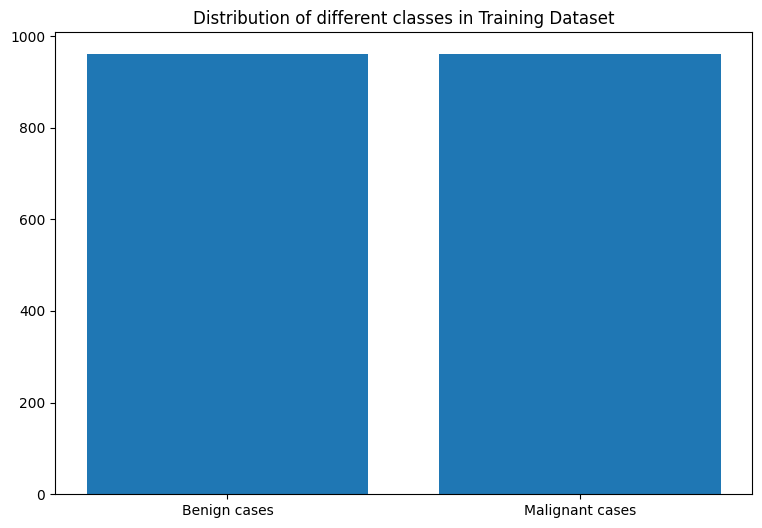

In [15]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread
import pathlib

image_folder = ['Benign cases', 'Malignant cases']
nimgs = {}
for i in image_folder:
    current_dir = os.path.join(train_dir, i)
    os.makedirs(current_dir, exist_ok=True)
    nimages = len(os.listdir(current_dir))
    nimgs[i] = nimages
    os.makedirs(current_dir, exist_ok=True) # Ensure directory exists
    nimages = len(os.listdir(current_dir))
    nimgs[i]=nimages
plt.figure(figsize=(9, 6))
plt.bar(range(len(nimgs)), list(nimgs.values()), align='center')
plt.xticks(range(len(nimgs)), list(nimgs.keys()))
plt.title('Distribution of different classes in Training Dataset')
plt.show()

In [16]:
import os
for i in ['Benign cases', 'Malignant cases']:
    print('Training {} images are: '.format(i)+str(len(os.listdir(os.path.join('C:\\Users\\Devar\\Desktop\\Lung Cancer Detection\\Dataset', i)))))

Training Benign cases images are: 1200
Training Malignant cases images are: 1201


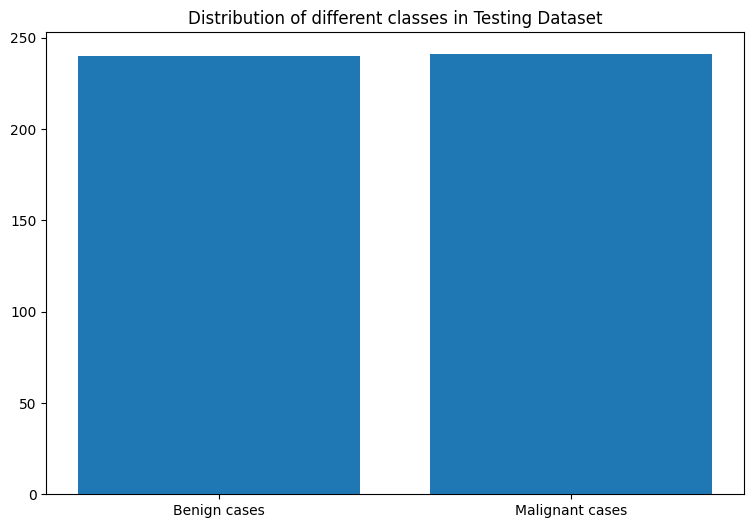

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread
import pathlib
import os

image_folder = ['Benign cases', 'Malignant cases']
nimgs = {}
for i in image_folder:
    current_dir = os.path.join(validation_dir, i)
    os.makedirs(current_dir, exist_ok=True)
    nimages = len(os.listdir(current_dir))
    nimgs[i] = nimages
plt.figure(figsize=(9, 6))
plt.bar(range(len(nimgs)), list(nimgs.values()), align='center')
plt.xticks(range(len(nimgs)), list(nimgs.keys()))
plt.title('Distribution of different classes in Testing Dataset')
plt.show()

In [19]:
!pip install tensorflow==2.21.0


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Dropout
from keras.layers import Flatten

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img

In [22]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=8,
                                   zoom_range=0.15,
                                   width_shift_range=0.15,
                                   height_shift_range=0.15,
                                   shear_range=0.10,
                                   horizontal_flip=True,
                                   brightness_range=[0.8,1.2],
                                   channel_shift_range=0.15,
                                   fill_mode="nearest")

In [23]:
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [26]:
x_train = train_datagen.flow_from_directory(
    train_dir,
    target_size=(299, 299),
    batch_size=32,
    class_mode='binary'
)

x_test = test_datagen.flow_from_directory(
    validation_dir,
    target_size=(299, 299),
    batch_size=32,
    class_mode='binary'
)

print(x_train.class_indices)
print(x_test.class_indices)

x_test = test_datagen.flow_from_directory(
    validation_dir,
    target_size=(299, 299),
    batch_size=32,
    class_mode='binary'
)

print(x_train.class_indices)
print(x_test.class_indices)

Found 1920 images belonging to 2 classes.
Found 481 images belonging to 2 classes.
{'Benign cases': 0, 'Malignant cases': 1}
{'Benign cases': 0, 'Malignant cases': 1}
Found 481 images belonging to 2 classes.
{'Benign cases': 0, 'Malignant cases': 1}
{'Benign cases': 0, 'Malignant cases': 1}


In [27]:
from tensorflow.keras.applications.inception_v3 import InceptionV3

In [28]:
from keras.models import Sequential

model = Sequential()
model.add(Convolution2D(32, (3, 3), input_shape=(224, 224, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(3, 3)))
model.add(Dropout(0.25))
model.add(Convolution2D(64, (3, 3), activation='relu'))
model.add(Convolution2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Convolution2D(128, (3, 3), activation='relu'))
model.add(Convolution2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(units=512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

c:\Users\Devar\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 70, 70, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 33, 33, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 31, 31, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    14,746,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,089,665 (57.56 MB)

 Trainable params: 15,089,665 (57.56 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
import tensorflow as tf
base_model=tf.keras.applications.inception_v3.InceptionV3(
    include_top=False,
    weights='imagenet',
    input_tensor=None,
    input_shape=(299,299,3),
    pooling=None,
    classes=1000,
    classifier_activation='softmax'
)
for layer in base_model.layers:
    layer.trainable=False

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [30]:
import tensorflow as tf
x=tf.keras.layers.Flatten()(base_model.output)
x=tf.keras.layers.Dense(512,activation='relu')(x)

x=tf.keras.layers.Dropout(0.5)(x)
x=tf.keras.layers.Dense(1,activation='sigmoid')(x)
model=tf.keras.models.Model(base_model.input,x)

In [31]:
model.compile(loss="binary_crossentropy",optimizer='adam',metrics=['accuracy'])

In [32]:
model.compile(loss="binary_crossentropy",optimizer='adam',metrics=['accuracy'])

In [33]:
TRAIN_STEPS_PER_EPOCH = len(x_train)
VAL_STEPS_PER_EPOCH = len(x_test)

print(f"TRAIN_STEPS_PER_EPOCH:{TRAIN_STEPS_PER_EPOCH}")
print(f"VAL_STEPS_PER_EPOCH:{VAL_STEPS_PER_EPOCH}")

TRAIN_STEPS_PER_EPOCH:60
VAL_STEPS_PER_EPOCH:16


In [1]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
EARLY_STOP_PATIENCE =5

In [4]:
import scipy

%pip uninstall -y scipy
%pip install --no-cache-dir scipy==1.13.1

%pip install scipy

cb_early_stopper = EarlyStopping(monitor='val_loss', patience=EARLY_STOP_PATIENCE)
cb_checkpointer = ModelCheckpoint(filepath='Inception_v3.weights.h5', monitor='val_loss', save_best_only=True, mode='auto', save_weights_only=True)
callbacks = [cb_checkpointer, cb_early_stopper]
# Install SciPy in the current Jupyter kernel
%pip install -q scipy

print("SciPy version:", scipy.__version__)

history = model.fit(
    x_train,
    steps_per_epoch=TRAIN_STEPS_PER_EPOCH,
    epochs=20,
    validation_data=x_test,
    validation_steps=VAL_STEPS_PER_EPOCH,
    callbacks=callbacks
)

C:\Users\Devar\AppData\Local\Temp\ipykernel_2896\3096255992.py:1: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.5.2)
  import scipy


Found existing installation: scipy 1.13.1
Uninstalling scipy-1.13.1:
  Successfully uninstalled scipy-1.13.1
Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.


   ---------------------------------------- 0.0/45.9 MB ? eta -:--:--
   --- ------------------------------------ 3.9/45.9 MB 21.3 MB/s eta 0:00:02
   ---------- ----------------------------- 11.5/45.9 MB 30.1 MB/s eta 0:00:02
   ---------- ----------------------------- 11.5/45.9 MB 30.1 MB/s eta 0:00:02
   ---------- ----------------------------- 12.6/45.9 MB 17.9 MB/s eta 0:00:02
   ------------ --------------------------- 14.7/45.9 MB 14.4 MB/s eta 0:00:03
   ------------------- -------------------- 22.5/45.9 MB 17.6 MB/s eta 0:00:02
   --------------------------- ------------ 31.5/45.9 MB 21.3 MB/s eta 0:00:01
   ------------------------------------ --- 41.9/45.9 MB 25.2 MB/s eta 0:00:01
   ---------------------------------------- 45.9/45.9 MB 25.9 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
SciPy version: 1.18.1


NameError: name 'model' is not defined

In [5]:
model.save("C:\\Users\\Devar\\Desktop\\Hertfordshire\\3rd Semester\\SOURCE CODE - Final\\Lung Cancer Detection\\Backend\\Inception_v3new.hdf5")

NameError: name 'model' is not defined

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import accuracy_score
import seaborn as sns
from sklearn.metrics import confusion_matrix


In [ ]:
y_pred=model.predict(x_test)
threshold=0.5
y_pred_threshold=[(1 if val>threshold else 0) for val in y_pred]
y_true=x_test.labels.tolist()
print(confusion_matrix(y_true,y_pred_threshold))
print(accuracy_score(y_true,y_pred_threshold))
sns.heatmap(confusion_matrix(y_true,y_pred_threshold),annot=True)


In [ ]:
y_pred = model.predict(x_test, verbose=1)
y_pred_bool = np.argmax(y_pred, axis=1)
#y_true=x_test.labels.tolist()



print(classification_report(y_true, y_pred_bool))

print(confusion_matrix(y_true, y_pred=y_pred_bool))

In [ ]:
keys=history.history.keys()
print(keys)

In [ ]:
plt.figure(1,figsize=(15,8))
plt.subplot(221)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model_Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train','valid'])

In [ ]:
plt.figure(1,figsize=(15,8))
plt.subplot(222)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model_loss')
plt.ylabel('loss')
plt.xlabel('Epoch')
plt.legend(['train','valid'])

plt.show()

In [ ]:
for key in keys:
  plt.figure(figsize=(15,2))
  plt.plot(history.history[key])
  plt.title(key)
  plt.ylabel(key)
  plt.xlabel('epoch')
  plt.legend(['train','valid'])

plt.show()

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import load_model
model=load_model('C:\\Users\\Devar\\Desktop\\Hertfordshire\\3rd Semester\\SOURCE CODE - Final\\Lung Cancer Detection\\Backend\\Inception_v3new.hdf5')

In [ ]:
from keras.preprocessing import image
import cv2
import numpy as np
import PIL
from PIL import Image

In [ ]:
img = image.load_img('C:\\Users\\Devar\\Desktop\\Hertfordshire\\3rd Semester\\SOURCE CODE - Final\\Lung Cancer Detection\\Backend\\Split_data_inception_V3_1\\validation\\Malignant cases\\auto_contrast (1).jpg',target_size=(299,299))

In [ ]:
x=image.img_to_array(img)
x=np.expand_dims(x,axis=0)
x.shape

In [ ]:
pred = model.predict(x)
pred

In [ ]:
class_names=["Bengin cases","Malignant cases"]
prediction = class_names[int(pred[0][0])]
print(pred[0][0])
print(prediction)

In [ ]:
!pip install pyngrok==4.1.1

In [ ]:
!pip install flask_ngrok
!ngrok authtoken 2L2K2jLowvwGqsOFktpa14xk1Av_5n8dboKu9yH1PkyoiCgx2 #Without "" marks

from flask_ngrok import run_with_ngrok
from flask import Flask, render_template

In [ ]:
!ls

In [ ]:
!pip install --upgrade gevent

In [ ]:
import os

os.makedirs('C:\\Users\\Devar\\Desktop\\Hertfordshire\\3rd Semester\\SOURCE CODE - Final\\Lung Cancer Detection\\Backend\\Webapp\\templates', exist_ok=True)
os.makedirs('C:\\Users\\Devar\\Desktop\\Hertfordshire\\3rd Semester\\SOURCE CODE - Final\\Lung Cancer Detection\\Backend\\Webapp\\static', exist_ok=True)

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import os

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from flask import Flask, request, render_template
from werkzeug.utils import secure_filename
from gevent.pywsgi import WSGIServer

In [ ]:
import cv2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
from flask_ngrok import run_with_ngrok
from flask import Flask, redirect, url_for, request, render_template
from werkzeug.utils import secure_filename
from gevent.pywsgi import WSGIServer

In [ ]:
MODEL_PATH = 'C:\\Users\\Devar\\Desktop\\Hertfordshire\\3rd Semester\\SOURCE CODE - Final\\Lung Cancer Detection\\Backend\\Inception_v3new.hdf5'
model = load_model(MODEL_PATH)
#print('Model Loaded. Check http://127.0.0.1:5000/')

In [ ]:
from flask import Flask, request, jsonify
from tensorflow.keras.preprocessing import image
import numpy as np

# Load the saved model
model = load_model('C:\\Users\\Devar\\Desktop\\Hertfordshire\\3rd Semester\\SOURCE CODE - Final\\Lung Cancer Detection\\Backend\\Inception_v3new.hdf5')

# Define a Flask app
app = Flask(__name__)

# Define a route for predicting the uploaded images
@app.route('/predict', methods=['POST'])
def predict():
    # Get the uploaded file from the request
    file = request.files['image']

    # Load the image and preprocess it
    img = image.load_img(file, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    # Make a prediction
    preds = model.predict(x)

    # Get the class label
    label = decode_predictions(preds, top=1)[0][0][1]

    # Return the prediction result
    return jsonify({'class': label})

if __name__ == '__main__':
    app.run(debug=True)

In [ ]:
!pip install flask_ngrok
from flask import Flask
from flask_ngrok import run_with_ngrok

app = Flask(__name__ )
run_with_ngrok(app)

if __name__ == '__main__':
    app.run()